# Proof of concept: Diffuse Correlation Spectroscopy
This notebook aims to replicate the measurements in the article titled _"Massively parallel, real-time multispeckle diffuse correlation spectroscopy using a 500 x 500 SPAD camera". 
Temporal auto-correlation ($g^{2}(\tau) = \frac{\langle n(t) n(t+\tau) \rangle}{\langle n(t)^2 \rangle}$) measurements are the central results of the article. 
The measurements are summarized in the following points: 
* The $g^{(2)} (\tau)$ and $\bar{g}^{(2)} (\tau)$ are calculated over *160* integration periods. 
    *  Loop over "decorrelation_24ch" save data for individual pixels and for the average. 
* STD is then calculated for a given $\tau$ bin. Paper reports $STD(g^{(2)} (10.8\mu s))=0.123$ and $STD(\bar{g}^{(2)}_{2.5e5} (10.8 \mu s))=2.6e-4$ 
* $SNR(g^{(2)} (\tau)) = mean_{160}(g^{(2)} (\tau)-1) / STD_{160}(g^{(2)} (\tau))$


## 1) Experimental Parameters 
The article reports the following experimental parameters: 
* Wavelenght $\lambda = 785 nm$ 
* Power $1 nW$
* PDP $15%$
* n-bins: 16
* Frame rate 93 fps. Exposure time $10.81 \mu s$
* Integration time 50 ms. Upper limit of $2^{16}$ exposures ($2^{16} = cps * T_{INT}$). 
* Pixel Diameter: $6\mu m$ similar to Speckle Diameter.
    * Pitch $16.38 \mu m$, Fill factor $10.6 \% $, circular active area, $z=11.5mm$

In [10]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from IPython.display import clear_output
import math

# DCS Parameters
t_int_ps = 8e12 # ps (e12 = seconds)
bin_width = 1_000e6 # ps (e6 = micro seconds)
n_bins = 21
num_periods = 10         # Number of frames to capture
target_bin = 1            # Index for the target tau bin (e.g., tau = 10.8 us)

# Calibration Parameters
t_exp_ps = 50e9 # exposure time
pixel_pitch_um = 125.0 # um 

## 2) Time Tagger Initialization
Connect to the Swabian Time Tagger hardware, configure the required input channels, and create a reference list for the active time-to-digital converters (TDC).

In [12]:
# Create Tagger Object and define available channels
print(f"Serial Numbers:{tt.scanTimeTagger()}") # Extract serial numbers
tagger = tt.createTimeTagger() # Create time tagger
spad_channels = np.array(tagger.getChannelList()) # Available Channels
spad_channels = spad_channels[spad_channels > 0] # Keep rising edges only (positive ch)

print(f"{len(spad_channels)} Available Channels : {spad_channels}") # Extract Channel List

Serial Numbers:()
36 Available Channels : [101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218]


## 3) Calibration: Contrate
Initialize a `CountRate` measurement instance using `spad_channels`. Display a live, updating plot of the count rates to adjust optical attenuation for optimal countrates. 

* Average detections per exposure $\langle n \rangle = 0.1$ with $T_{EX} = 10.81 \mu s$ == $9.25 kcps$


In [13]:
# block uses: t_exp_ps
# Create Countrate object
cr = tt.Countrate(tagger, channels=spad_channels)

channel_labels = [str(ch) for ch in spad_channels]

try:
    for _ in range(1000): #Define number of updates
        # Measure Countrates from object
        cr.startFor(t_exp_ps,clear=True)
        cr.waitUntilFinished()
        rates = cr.getData()
        #Visualize (Histogram)
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.bar(channel_labels, rates, color='cadetblue', edgecolor='black')
        plt.ylim(0,1.5e6) # Adjust limit to expected countrates
        plt.title("Live SPAD Line Sensor Count Rates")
        plt.xlabel("SPAD Channel")
        plt.ylabel("Counts per second (cps)")
        plt.xticks(channel_labels)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
except KeyboardInterrupt:
    print("Monitor interrupted.")

Monitor interrupted.


## 4)  Calibration: Speckle Size Measurement
Incident laser light on a scattering medium () produce a random interference effect also known as a speckle field. 
Capturing a count rate frame across the SPAD array in front of the diffuser generates a "picture" of the speckle field. 
To ensure individual pixels capture a single speckle, a calculation the spatial autocorrelation of the intensity pattern using `numpy.correlate` is done.
The Full Width at Half Maximum (FWHM) of the correlation peak to define the average speckle size. 

--- Speckle Size Calibration Results ---
100-Series Row: FWHM = 4.85 pixels | Physical Size = 606.4 µm
200-Series Row: FWHM = 4.74 pixels | Physical Size = 592.3 µm


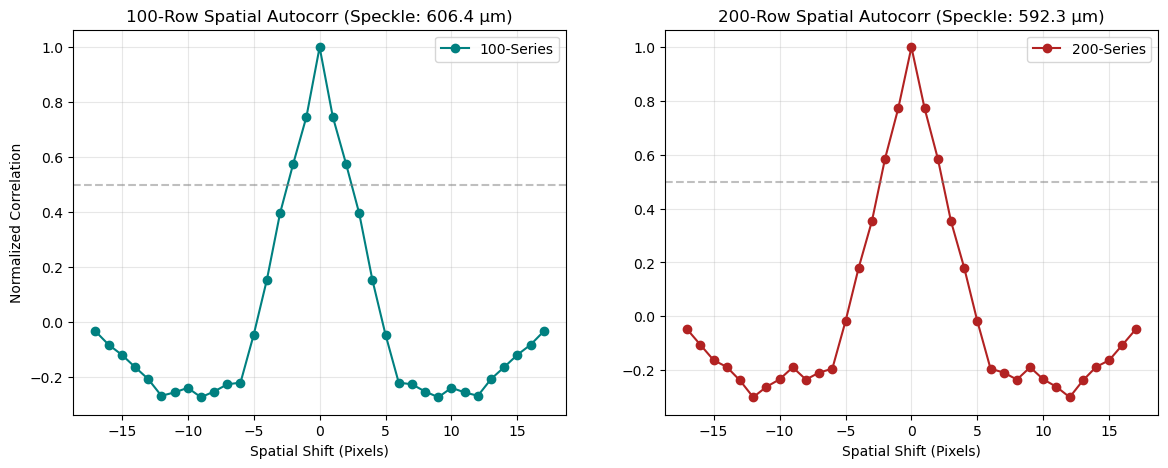

In [14]:
# block uses: t_exp_ps
cr =tt.Countrate(tagger,spad_channels)
cr.startFor(t_exp_ps, clear=True)
cr.waitUntilFinished()
rates = cr.getData()

# Map channels to countrates
rates_map = dict(zip(spad_channels,rates))

# Separate channels 
row_100 = spad_channels[spad_channels<199]
row_200 = spad_channels[spad_channels>199]

# Compute spatial autocorrelation
def spatial_autocorr_with_fwhm(row):
    if len(row) > 0:
        rates = np.array([rates_map[ch] for ch in row])
        fluc = rates - np.mean(rates)
        autocorr = np.correlate(fluc, fluc, mode='full')

        if np.max(autocorr) > 0:
            autocorr = autocorr / np.max(autocorr)

        shifts = np.arange(-len(row) + 1, len(row))
        
        # FWHM Calculation
        above_half = np.where(autocorr >= 0.5)[0]    # indices where the correlation is above 0.5
        
        if len(above_half) > 0:
            # Left crossing interpolation
            left_idx = above_half[0]
            if left_idx > 0:
                x0, x1 = shifts[left_idx - 1], shifts[left_idx]
                y0, y1 = autocorr[left_idx - 1], autocorr[left_idx]
                left_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                left_cross = shifts[left_idx]

            # Right crossing interpolation
            right_idx = above_half[-1]
            if right_idx < len(autocorr) - 1:
                x0, x1 = shifts[right_idx], shifts[right_idx + 1]
                y0, y1 = autocorr[right_idx], autocorr[right_idx + 1]
                right_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                right_cross = shifts[right_idx]

            fwhm_pixels = right_cross - left_cross
        else:
            fwhm_pixels = 0.0

        return autocorr, shifts, fwhm_pixels
    else:
        print("Error: Empty row provided.")
        return None, None, 0.0

# Extract data and FWHM
autocorr_100, shifts_100, fwhm_100 = spatial_autocorr_with_fwhm(row_100)
autocorr_200, shifts_200, fwhm_200 = spatial_autocorr_with_fwhm(row_200)

# Calculate physical speckle sizes
speckle_size_100_um = fwhm_100 * pixel_pitch_um
speckle_size_200_um = fwhm_200 * pixel_pitch_um

print(f"--- Speckle Size Calibration Results ---")
print(f"100-Series Row: FWHM = {fwhm_100:.2f} pixels | Physical Size = {speckle_size_100_um:.1f} µm")
print(f"200-Series Row: FWHM = {fwhm_200:.2f} pixels | Physical Size = {speckle_size_200_um:.1f} µm")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if autocorr_100 is not None:
    ax1.plot(shifts_100, autocorr_100, marker='o', color='teal', label='100-Series')
    ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f"100-Row Spatial Autocorr (Speckle: {speckle_size_100_um:.1f} µm)")
    ax1.set_xlabel("Spatial Shift (Pixels)")
    ax1.set_ylabel("Normalized Correlation")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

if autocorr_200 is not None:
    ax2.plot(shifts_200, autocorr_200, marker='o', color='firebrick', label='200-Series')
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title(f"200-Row Spatial Autocorr (Speckle: {speckle_size_200_um:.1f} µm)")
    ax2.set_xlabel("Spatial Shift (Pixels)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.show()

## 5) Diffuse Correlation Spectroscopy
* The $g^{(2)} (\tau)$ and $\bar{g}^{(2)} (\tau)$ are calculated over *160* integration periods. 
    *  Loop over "decorrelation_24ch" save data for individual pixels and for the average. 
* STD is then calculated for a given $\tau$ bin. Paper reports $STD(g^{(2)} (10.8\mu s))=0.123$ and $STD(\bar{g}^{(2)}_{2.5e5} (10.8 \mu s))=2.6e-4$ 
* $SNR(g^{(2)} (\tau)) = mean_{160}(g^{(2)} (\tau)-1) / STD_{160}(g^{(2)} (\tau))$

In [15]:
# Measurement function
def measure_autocorrelation(tagger, channels, t_int_ps, bin_width, n_bins, periods=160):
    """
    Measures autocorrelation histograms of all channels over a number of periods.
    """
    num_ch = len(channels)
    raw_hists = np.zeros((periods, num_ch, n_bins))
    tau_axis = None

    print(f"Start {periods} measurement periods...")

    for p in range(periods):
        correlations = []
        
        # Initialize correlation objects
        for ch in channels:
            corr = tt.Correlation(tagger, ch, ch, binwidth=bin_width, n_bins=n_bins)
            correlations.append(corr)

        # Start hardware clock
        tagger.sync()
        for corr in correlations:
            corr.startFor(t_int_ps, clear=True)

        # Wait and extract raw data
        for i, corr in enumerate(correlations):
            corr.waitUntilFinished()
            hist = corr.getData()
            
            if tau_axis is None:
                tau_axis = corr.getIndex()
            
            raw_hists[p, i, :] = hist

    print("Measurement complete. Raw histograms extracted.")
    return tau_axis, raw_hists

In [16]:
# Run the function
tau_axis, raw_hists = measure_autocorrelation(
    tagger=tagger, 
    channels=spad_channels, 
    t_int_ps=t_int_ps, 
    bin_width=bin_width, 
    n_bins=n_bins, 
    periods=num_periods
)

Start 10 measurement periods...
Measurement complete. Raw histograms extracted.


Plotting raw histograms for period 0...


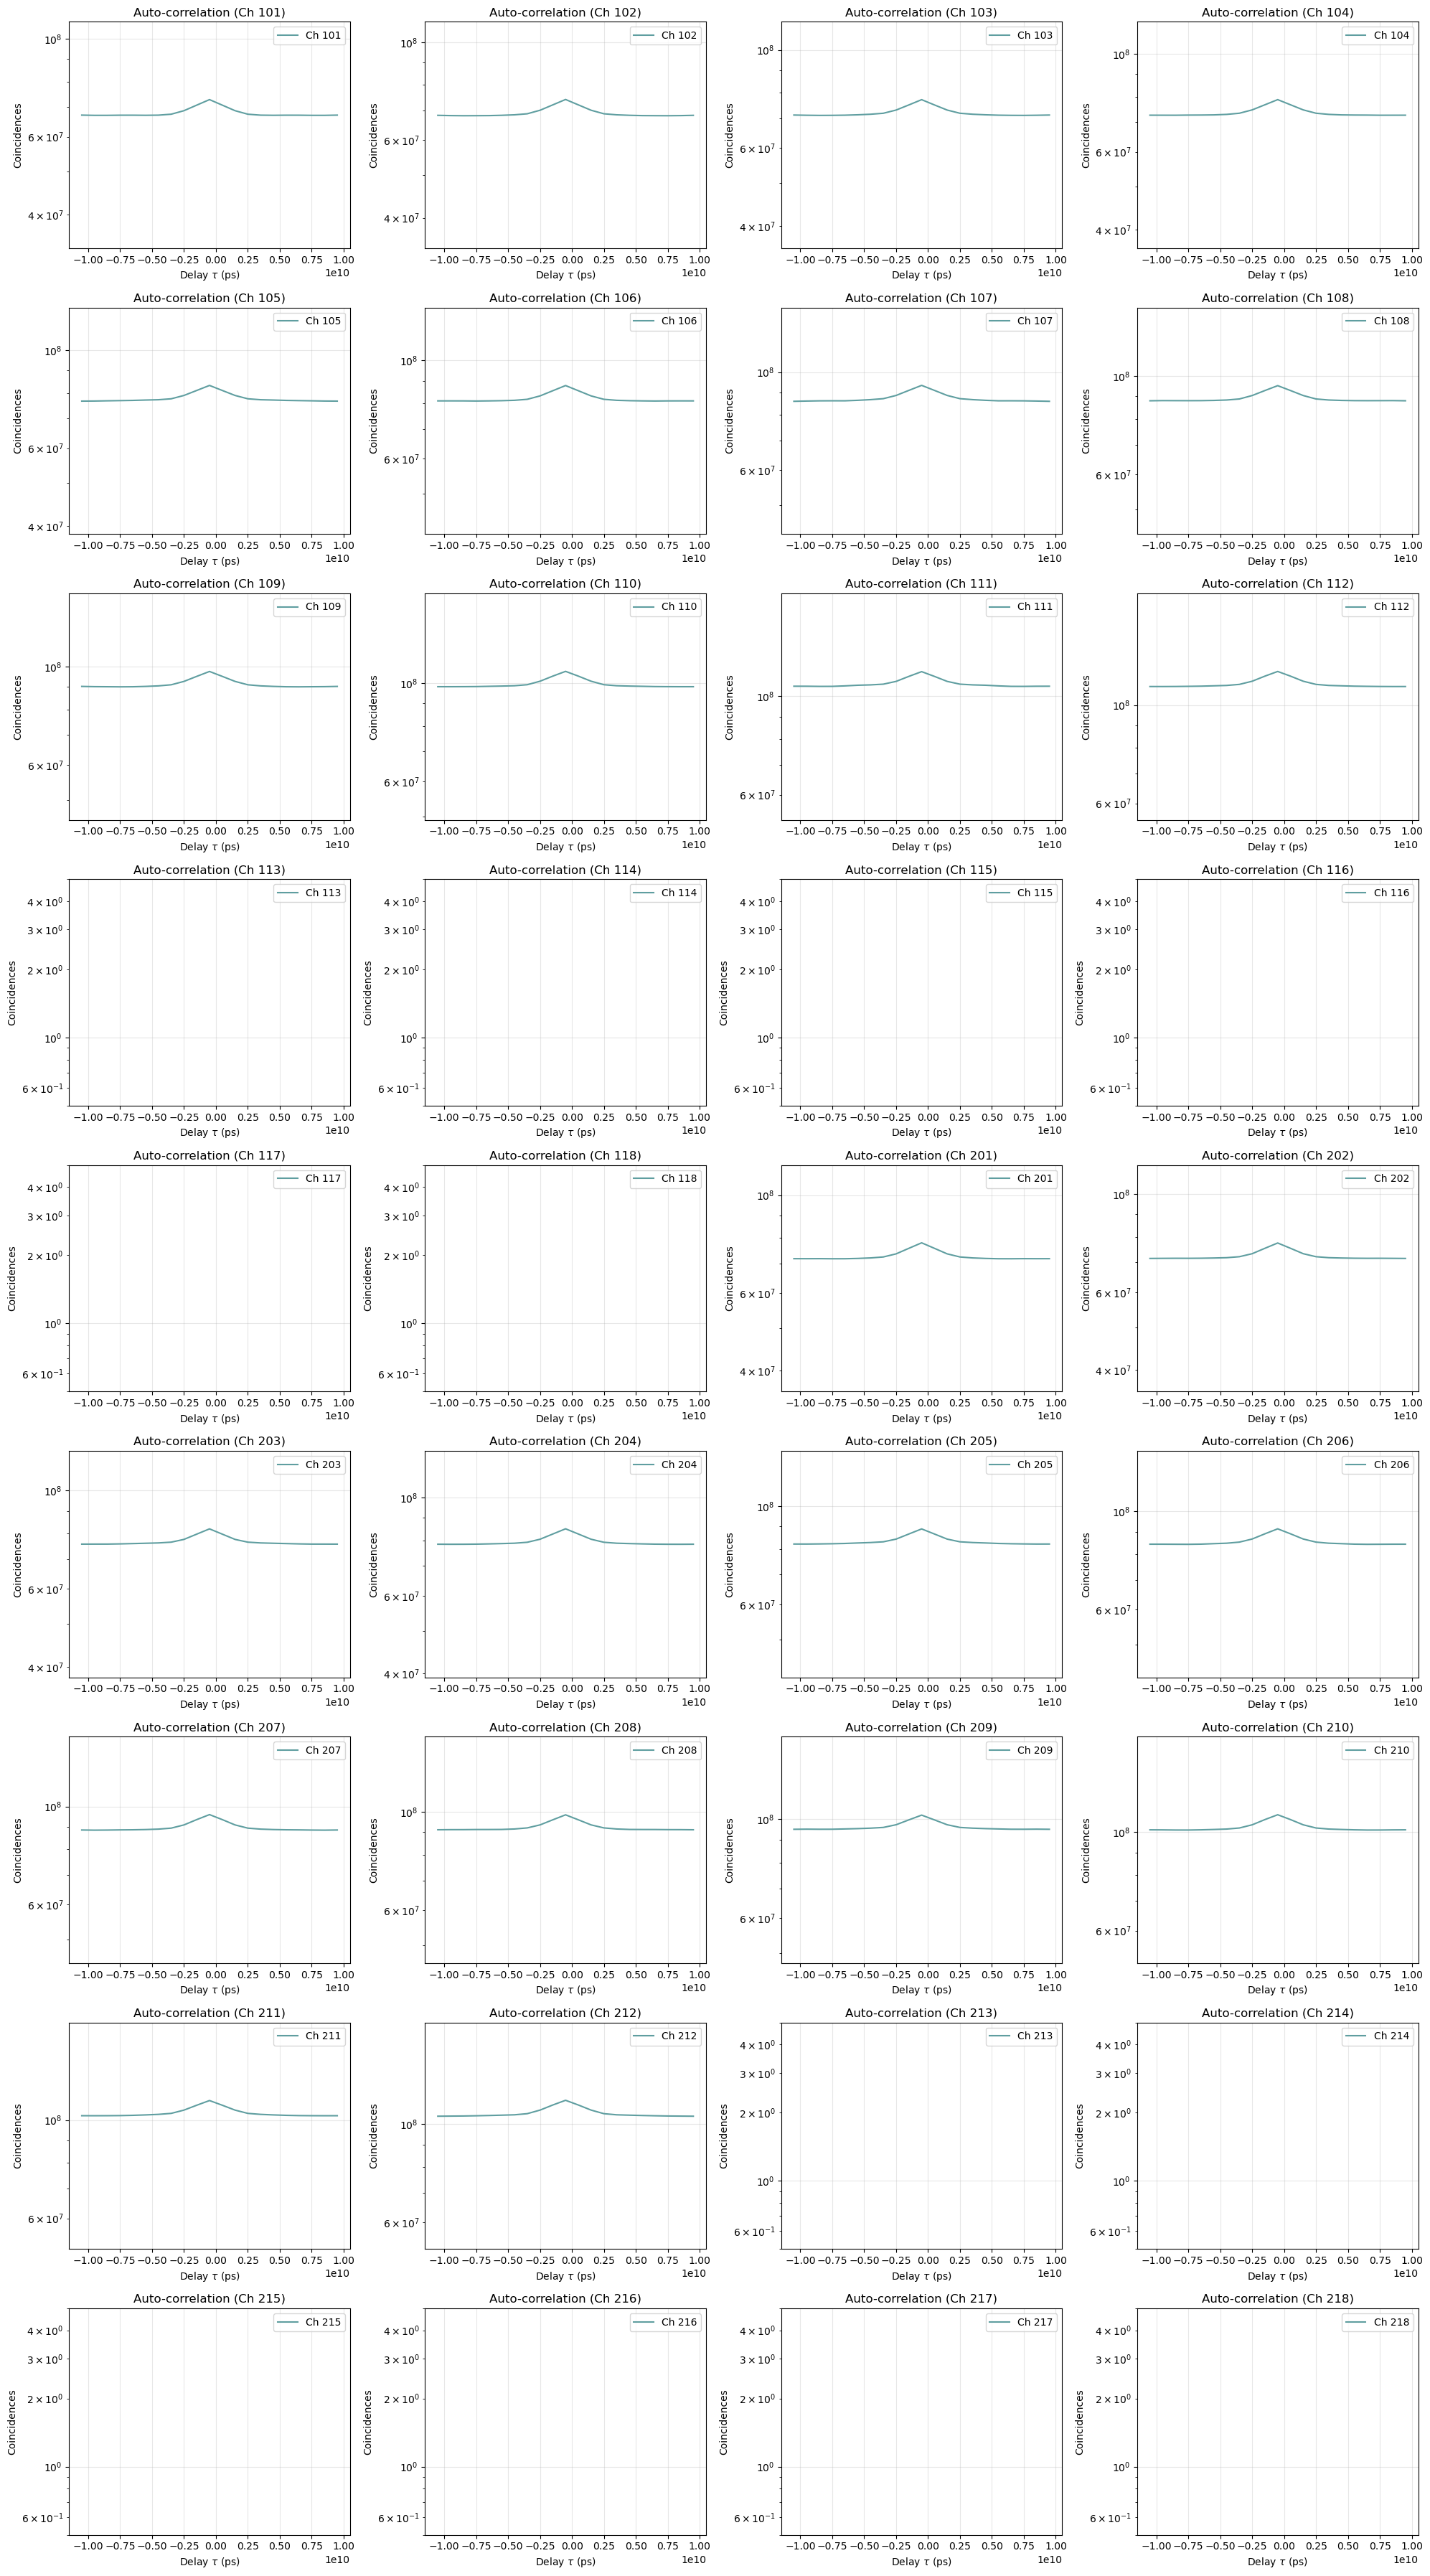

In [ ]:
# Prelim: Visualization

plot_period = 0 # Select the integration period
print(f"Plotting raw histograms for period {plot_period}...")

num_plots = len(spad_channels)
cols = min(4, num_plots)
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.atleast_1d(axes).flatten()

for idx, ch in enumerate(spad_channels):
    ax = axes[idx]
    t_plot = tau_axis  # Time delay in picoseconds
    hist_plot = raw_hists[plot_period, idx, :]
    
    # Calculate baseline from the last 10 percent of the histogram
    tail_length = int(len(hist_plot) * 0.1)
    if tail_length == 0:
        tail_length = 1
        
    baseline_avg = np.mean(hist_plot[-tail_length:])
    
    # Prevent errors with the logarithmic scale
    if baseline_avg <= 0:
        baseline_avg = 1.0
        
    y_min = baseline_avg * 0.50
    y_max = np.max(hist_plot) * 1.50
    
    if y_max <= y_min:
        y_max = y_min * 10

    ax.plot(t_plot, hist_plot, color='cadetblue', linewidth=1.5, label=f'Ch {ch}')
    ax.set_ylim([y_min, y_max])
    ax.set_yscale('log')
    ax.set_title(f"Auto-correlation (Ch {ch})")
    ax.set_xlabel(r"Delay $\tau$ (ps)")
    ax.set_ylabel("Coincidences")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
# Hide the subplots that do not have data
for i in range(num_plots, len(axes)):
    axes[i].set_visible(False)
    
plt.tight_layout()
plt.show()

In [ ]:
#save data 
from datetime import datetime

# 1. Define the target directory
save_dir = "../data/raw/decorrelation"

# Create the directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# 2. Create a unique filename with a timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"raw_autocorr_{timestamp}.npz"
filepath = os.path.join(save_dir, filename)

# 3. Save the data arrays
print(f"Saving raw data to {filepath}...")
np.savez_compressed(
    filepath,
    tau_axis=tau_axis,
    raw_hists=raw_hists,
    channels=spad_channels
)

print("Data saved successfully.")

Saving raw data to .data/raw/decorrelation\raw_autocorr_20260807_200133.npz...
Data saved successfully.


# DATA ANALYSIS

The article compares the standard deviation of a single pixel with the standard deviation of the spatial average.

* Clean the Data
* Normalize the Data
* Fit the Model
* Extract Parameters ($\tau_c$ value)

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from scipy.optimize import curve_fit 

In [40]:
data_dir = "../data/raw/decorrelation/"
data_file = "raw_autocorr_20260807_200133.npz"
data = np.load(os.path.join(data_dir,data_file))
print(data)

NpzFile '../data/raw/decorrelation/raw_autocorr_20260807_200133.npz' with keys: tau_axis, raw_hists, channels


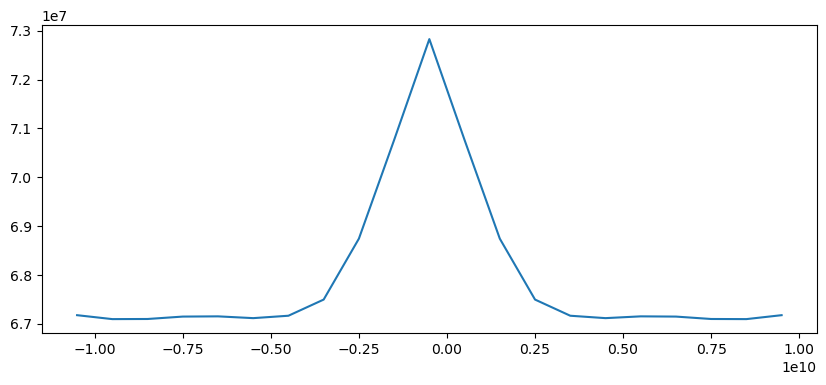

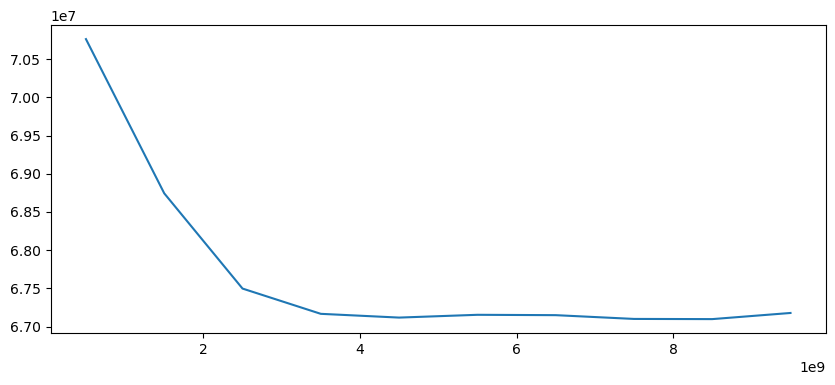

In [41]:
tau = data['tau_axis']
counts = data['raw_hists']

plt.figure(figsize=(10,4))
plt.plot(tau, counts[0][0])

valid_indices = tau>=100   ##

tau = tau[valid_indices]
counts = counts[:,:,valid_indices]

plt.figure(figsize=(10,4))
plt.plot(tau, counts[0][0])


In [42]:
def normalize(counts, tail_bins=5):
    # Calculate the baseline from the last time bins
    baseline = np.mean(counts[..., -tail_bins:], axis=-1, keepdims=True)
    
    # Divide the raw counts by the baseline
    g2 = counts / baseline
    
    return g2


def ballistic_model(tau, beta, tau_c):
    # Calculate the ballistic model with a negative squared exponent
    return 1 + beta * np.exp(-(tau / tau_c)**2)

def fit_g2(tau, g2_data):
    # Dynamic initial parameter guesses based on input data
    tail_length = max(1, int(len(g2_data) * 0.1))
    baseline_guess = np.nanmean(g2_data[-tail_length:])
    
    peak_guess = np.nanmax(g2_data)
    beta_guess = peak_guess - baseline_guess
    
    # Find the tau_c guess at the 1/e decay point
    threshold = baseline_guess + (beta_guess * np.exp(-1))
    
    try:
        decay_idx = np.where(g2_data < threshold)[0][0]
        tau_c_guess = tau[decay_idx]
    except IndexError:
        tau_c_guess = np.mean(tau) # Fallback if data is too noisy
        
    # Match the ballistic_model parameter order: beta, tau_c
    initial_guesses = [beta_guess, tau_c_guess] 
    
    try:
        popt, pcov = curve_fit(ballistic_model, tau, g2_data, p0=initial_guesses)
        beta_fit = popt[0]
        tau_c_fit = popt[1]
        return tau_c_fit, beta_fit
        
    except RuntimeError:
        print("Warning: The curve fit failed. Returning initial guesses.")
        return initial_guesses[1], initial_guesses[0]


def analyze_g2_data(tau, g2_data, target_bin):
    # Calculate the standard deviation across all iterations for the target bin.
    # g2_data dimension 0 is the iterations.
    std_target = np.std(g2_data[:, target_bin], axis=0)
    
    # Calculate the mean across all iterations to get the final g2 curve.
    avg_g2 = np.mean(g2_data, axis=0)
    
    # Fit the average curve to the ballistic model.
    tau_c, beta = fit_g2(tau, avg_g2)
    
    return avg_g2, std_target, tau_c, beta


def plot_g2_results(tau, g2_background, avg_g2, tau_c, beta, std_val, title="Multi-Speckle Average Fit"):
    """
    Plots the g2 correlation results, fit, and standard deviation.
    
    Parameters:
    tau: 1D array, delay time axis (in picoseconds)
    g2_background: 2D array, individual curves for the background (e.g., iterations)
    avg_g2: 1D array, the averaged g2 data to be fitted
    tau_c: float, extracted correlation time (in picoseconds)
    beta: float, extracted coherence factor from the fit
    std_val: float, standard deviation of the target bin
    title: str, title of the plot
    """
    # Convert tau from picoseconds to microseconds for the plot
    tau_us = tau / 1e6
    tau_c_us = tau_c / 1e6
    
    plt.figure(figsize=(8, 5))

    # Plot individual normalized g_2 curves in the background
    if g2_background is not None:
        label_added = False
        # Loop through the first dimension (iterations or pixels)
        for i in range(g2_background.shape[0]):
            if not label_added:
                plt.plot(tau_us, g2_background[i], '-', color='gray', alpha=0.25, linewidth=0.8, label="Individual Curves")
                label_added = True
            else:
                plt.plot(tau_us, g2_background[i], '-', color='gray', alpha=0.25, linewidth=0.8)

    # Plot the normalized averaged data
    plt.scatter(tau_us, avg_g2, color='cadetblue', alpha=1, s=20, zorder=3, label="Averaged Data")

    # Plot the mathematical fit using the ballistic_model
    fit_line_avg = ballistic_model(tau, beta, tau_c)
    plt.plot(tau_us, fit_line_avg, '-', color='cadetblue', linewidth=1, zorder=4, label=f"Fit ($\\tau_c$ = {tau_c_us:.2f} µs)")

    # Calculate Y-value at tau_c to plot the marker accurately
    tau_c_y = ballistic_model(tau_c, beta, tau_c)

    # Add a vertical boundary line and an 'x' marker for tau_c
    plt.axvline(x=tau_c_us, color='gray', linestyle='--', alpha=0.7, zorder=1, label="$\\tau_c$ Boundary")
    plt.scatter([tau_c_us], [tau_c_y], color='black', marker='x', s=80, zorder=5)

    # Display the Standard Deviation in a text box
    text_str = f"STD: {std_val:.4f}"
    plt.text(0.95, 0.5, text_str, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='lightgray'), 
             zorder=6)

    # Apply formatting
    plt.title(title, fontsize=14)
    plt.xlabel("Delay $\\tau$ (µs)", fontsize=12)
    plt.ylabel("$g^{(2)}(\\tau)$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', fontsize=10, fancybox=True)
    plt.tight_layout()
    plt.show()

In [36]:
target_bin = 0

1633651739.032277


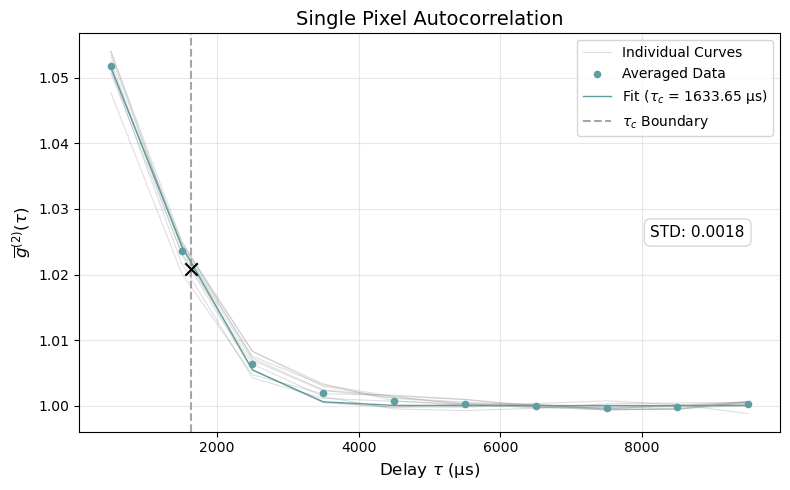

In [37]:
# Extract data for pixel index 0
pixel_counts = counts[:, 0, :]

# Normalize the data
g2_pixel = normalize(pixel_counts)

# Analyze the data
avg_g2_pixel, std_pixel, tau_c_pixel, beta_pixel = analyze_g2_data(tau, g2_pixel, target_bin)
print(tau_c_pixel)

# Visualize
plot_g2_results(
    tau=tau, 
    g2_background=g2_pixel, 
    avg_g2=avg_g2_pixel, 
    tau_c=tau_c_pixel, 
    beta=beta_pixel, 
    std_val=std_pixel, 
    title="Single Pixel Autocorrelation"
)

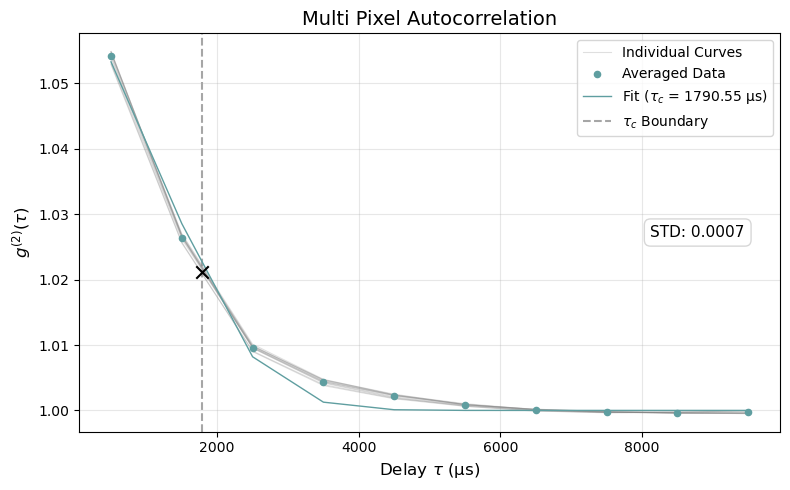

In [43]:
# Sum the counts across the iteration axis (0) and the tau axis (2)
valid_pixels_mask = np.sum(counts, axis=(0, 2)) > 0

# Keep only the valid pixels in the array
filtered_counts = counts[:, valid_pixels_mask, :]

# Normalize the data across individual pixel functions
g2_all = normalize(filtered_counts)

# Calculate the collective data mean across the pixel axis (1)
g2_spatial_avg = np.mean(g2_all, axis=1)

# Analyze the data
avg_g2_global, std_global, tau_c_global, beta_global = analyze_g2_data(tau, g2_spatial_avg, target_bin)

#Visualize
plot_g2_results(
    tau=tau, 
    g2_background=g2_spatial_avg, 
    avg_g2=avg_g2_global, 
    tau_c=tau_c_global, 
    beta=beta_global, 
    std_val=std_global, 
    title="Multi Pixel Autocorrelation"
)

In [48]:

def plot_std_vs_periods(g2_data, target_bin, title="Noise Reduction vs Periods"):
    """
    Calculate and plot the standard deviation as the number of periods increases.
    
    Parameters:
    - g2_data: 2D array (periods, tau_bins) containing normalized g2 data.
    - target_bin: int, the index of the delay bin to analyze.
    - title: str, the title for the plot.
    """
    # Get the maximum number of periods from the data.
    max_periods = g2_data.shape[0]
    
    # Make a list of period numbers. Start from 2 to calculate standard deviation.
    num_periods_list = np.arange(3, max_periods + 1)
    meas_stdv = []
    
    # Calculate the standard deviation for each subset of periods.
    for n in num_periods_list:
        subset = g2_data[:n, target_bin]
        std_val = np.std(subset)
        meas_stdv.append(std_val)
        
    meas_stdv = np.array(meas_stdv)
    
    # Calculate the theoretical curve.
    theoretical_stdv = meas_stdv[0] / np.sqrt(num_periods_list - num_periods_list[0] + 1)
    
    # Plot the data.
    plt.figure(figsize=(8, 5))
    plt.scatter(num_periods_list, meas_stdv, color='cadetblue', alpha=1, s=30, zorder=3, label="Measured STD")
    plt.plot(num_periods_list, theoretical_stdv, '-', color='gray', linewidth=1.5, zorder=4, label="Theoretical $1/\\sqrt{N}$")
    
    plt.title(title, fontsize=14)
    plt.xlabel("Number of Periods ($N$)", fontsize=12)
    plt.ylabel("Standard Deviation of $\\overline{g}^{(2)}(\\tau)$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right', fontsize=10, fancybox=True)
    plt.tight_layout()
    plt.show()


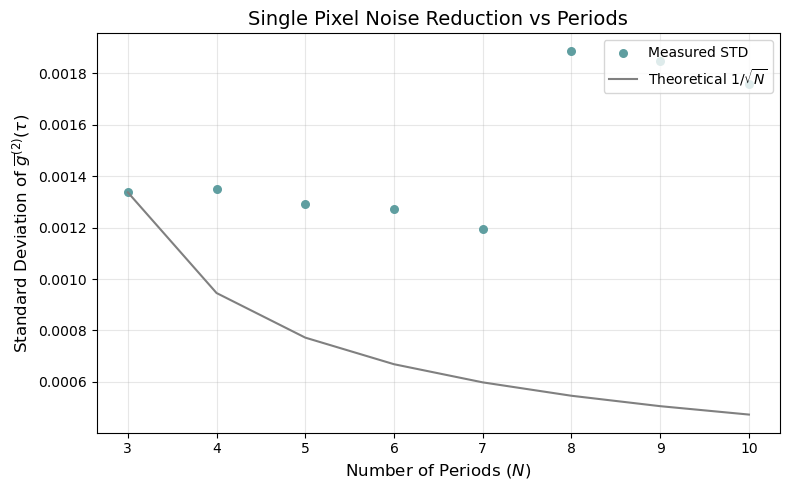

In [49]:

# Analyze the standard deviation for pixel index 0.
plot_std_vs_periods(g2_pixel, target_bin, title="Single Pixel Noise Reduction vs Periods")

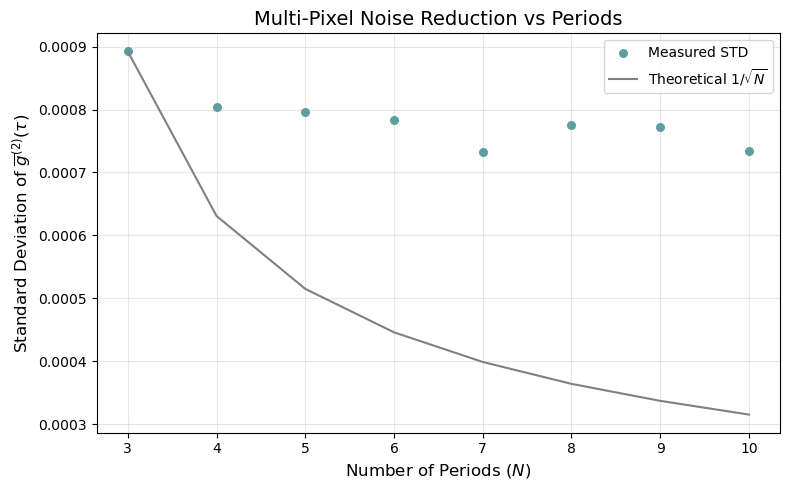

In [50]:
# Analyze the standard deviation for the spatial average.
plot_std_vs_periods(g2_spatial_avg, target_bin, title="Multi-Pixel Noise Reduction vs Periods")